In [1]:
from google.cloud import bigquery
from matplotlib.ticker import StrMethodFormatter
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [52]:
list_of_all_inst = client.query(f"""
                                SELECT DISTINCT inst_name, dfg_inst_id, ror as ror_id, sector, federal_state
                                FROM `subugoe-collaborative.resources.inst_with_federal_state` AS f
                                JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb
                                    ON CASE
                                        WHEN kb.inst_id = 621 THEN 'https://ror.org/03m2kj587'
                                        ELSE kb.ror 
                                    END = CONCAT('https://ror.org/', f.ror_id)
                                LEFT JOIN UNNEST(current_sectors) AS sector
                                WHERE federal_state = 'Niedersachsen' 
                                  AND sector IN ('uni', 'fh', 'khmh') 
                                  AND dfg_inst_id NOT IN (
                                    220269952, -- Fachhochschule für die Wirtschaft Hannover (FHDW)
                                    13033, -- PFH Private Hochschule Göttingen
                                    233118106, -- Leibniz-Fachhochschule
                                    198800578, -- Hochschule 21 Buxtehude
                                    195374963 -- Hochschule Weserbergland
                                  )
                               """).to_dataframe()

In [53]:
list_of_all_inst

,inst_name,dfg_inst_id,ror_id,sector,federal_state
0,Leuphana Universität Lüneburg,10232,https://ror.org/02w2y2t16,uni,Niedersachsen
1,Carl von Ossietzky Universität Oldenburg,10233,https://ror.org/033n9gh91,uni,Niedersachsen
2,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,10533,https://ror.org/02vvvm705,fh,Niedersachsen
3,Hochschule Emden/Leer,980710,https://ror.org/01bc76c69,fh,Niedersachsen
4,Gottfried Wilhelm Leibniz Universität Hannover,10238,https://ror.org/0304hq317,uni,Niedersachsen
5,"Hochschule für Musik, Theater und Medien Hannover",10246,https://ror.org/00x67m532,khmh,Niedersachsen
6,Hochschule Hannover,10252,https://ror.org/03z6vda50,fh,Niedersachsen
7,Stiftung Tierärztliche Hochschule Hannover,10249,https://ror.org/015qjqf64,uni,Niedersachsen
8,Medizinische Hochschule Hannover (MHH),10247,https://ror.org/00f2yqf98,uni,Niedersachsen
9,Hochschule für angewandte Wissenschaft und Kun...,10253,https://ror.org/00f5q5839,fh,Niedersachsen


Nicht enthalten: https://ror.org/02743t710 (Norddeutsche Hochschule für Rechtspflege)

#### Wichtig: Universitätsmedizin Göttingen wird in GERIT und in der Bielefelder Institutionskodierung zur Universität Göttingen gezählt!

ROR UMG: https://ror.org/021ft0n22

ROR GAU: https://ror.org/01y9bpm73

In [28]:
oal_inst_lower_saxony_raw = client.query(f"""
                            SELECT DISTINCT 
                                kb.id AS kb_id, 
                                oal.id AS oal_id, 
                                kb.source AS kb_source, 
                                oal.source AS oal_source,
                                kb.inst_name AS kb_name,
                                oal.inst_name AS oal_name,
                                kb.sector AS kb_sector,
                                oal.sector AS oal_sector
                            FROM (
                                SELECT o.id, sector, federal_states.inst_name, 'KB' AS source
                                FROM `subugoe-collaborative.openbib.kb_a_addr_inst` AS inst
                                JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb_inst
                                  ON inst.inst_id_top = kb_inst.inst_id
                                JOIN `subugoe-collaborative.resources.inst_with_federal_state` AS federal_states
                                  ON CASE
                                        WHEN kb_inst.inst_id = 621 THEN 'https://ror.org/03m2kj587'
                                        ELSE kb_inst.ror 
                                      END = CONCAT('https://ror.org/', federal_states.ror_id)
                                JOIN `subugoe-collaborative.openalex_walden.works` AS o
                                    ON inst.openalex_id = o.id
                                LEFT JOIN UNNEST(current_sectors) AS sector
                                WHERE publication_year BETWEEN 2020 AND 2024 
                                  AND type IN ('article', 'review')
                                  AND is_xpac=FALSE
                                  AND federal_states.federal_state = 'Niedersachsen'
                                  AND sector IN ('uni', 'fh', 'khmh') 
                                  AND dfg_inst_id NOT IN (
                                    220269952, -- Fachhochschule für die Wirtschaft Hannover (FHDW)
                                    13033, -- PFH Private Hochschule Göttingen
                                    233118106, -- Leibniz-Fachhochschule
                                    198800578, -- Hochschule 21 Buxtehude
                                    195374963 -- Hochschule Weserbergland
                                  )
                            ) AS kb
                            FULL OUTER JOIN (
                              SELECT o.id, sector, federal_states.inst_name, 'OAL' AS source
                                FROM (
                                  SELECT oal.id, 
                                         CASE 
                                          WHEN inst.ror = 'https://ror.org/021ft0n22' THEN 'https://ror.org/01y9bpm73'
                                          ELSE inst.ror
                                         END AS ror
                                  FROM `subugoe-collaborative.openalex_walden.works` AS oal, UNNEST(authorships) AS aut, UNNEST(aut.institutions) AS inst
                                  WHERE publication_year BETWEEN 2020 AND 2024 
                                  AND oal.type IN ('article', 'review')
                                  AND is_xpac=FALSE
                                ) AS o
                                JOIN `subugoe-collaborative.resources.inst_with_federal_state` AS federal_states
                                    ON o.ror = CONCAT('https://ror.org/', federal_states.ror_id)
                                LEFT JOIN `subugoe-collaborative.openbib.kb_inst_lookup` AS kb_inst
                                    ON CASE
                                        WHEN kb_inst.inst_id = 621 THEN 'https://ror.org/03m2kj587'
                                        ELSE kb_inst.ror 
                                    END = CONCAT('https://ror.org/', federal_states.ror_id)
                                LEFT JOIN UNNEST(current_sectors) AS sector
                                WHERE federal_states.federal_state = 'Niedersachsen'
                                    AND sector IN ('uni', 'fh', 'khmh') 
                                      AND dfg_inst_id NOT IN (
                                        220269952, -- Fachhochschule für die Wirtschaft Hannover (FHDW)
                                        13033, -- PFH Private Hochschule Göttingen
                                        233118106, -- Leibniz-Fachhochschule
                                        198800578, -- Hochschule 21 Buxtehude
                                        195374963 -- Hochschule Weserbergland
                                      )
                            ) AS oal
                              ON kb.id = oal.id
                            """).to_dataframe()

In [30]:
oal_inst_lower_saxony = oal_inst_lower_saxony_raw.copy()

In [31]:
oal_inst_lower_saxony

,kb_id,oal_id,kb_source,oal_source,kb_name,oal_name,kb_sector,oal_sector
0,https://openalex.org/W4392743243,https://openalex.org/W4392743243,KB,OAL,Hochschule Hannover,Hochschule Hannover,fh,fh
1,https://openalex.org/W4391381595,https://openalex.org/W4391381595,KB,OAL,Hochschule Hannover,Hochschule Hannover,fh,fh
2,https://openalex.org/W4388916333,https://openalex.org/W4388916333,KB,OAL,Hochschule Emden/Leer,Hochschule Emden/Leer,fh,fh
3,https://openalex.org/W4291452731,https://openalex.org/W4291452731,KB,OAL,Universität Vechta,Carl von Ossietzky Universität Oldenburg,uni,uni
4,https://openalex.org/W4405721050,https://openalex.org/W4405721050,KB,OAL,Hochschule Hannover,Hochschule Hannover,fh,fh
...,...,...,...,...,...,...,...,...
88985,https://openalex.org/W3151200663,https://openalex.org/W3151200663,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni
88986,https://openalex.org/W4387518142,https://openalex.org/W4387518142,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni
88987,https://openalex.org/W4362719562,https://openalex.org/W4362719562,KB,OAL,Universität Osnabrück,Universität Osnabrück,uni,uni
88988,https://openalex.org/W4403693256,https://openalex.org/W4403693256,KB,OAL,Universität Osnabrück,Leuphana Universität Lüneburg,uni,uni


In [32]:
oal_inst_lower_saxony.kb_source.count()

79889

In [33]:
oal_inst_lower_saxony.oal_source.count()

86513

In [34]:
kb_list = oal_inst_lower_saxony.groupby('kb_id')['kb_name'].apply(set).reset_index()

In [35]:
oal_list = oal_inst_lower_saxony.groupby('oal_id')['oal_name'].apply(set).reset_index()

In [36]:
inst_list = pd.merge(kb_list, oal_list, left_on='kb_id', right_on='oal_id', how='outer')

In [37]:
inst_list['kb_name'] = inst_list['kb_name'].fillna('').apply(set)
inst_list['oal_name'] = inst_list['oal_name'].fillna('').apply(set)

inst_list['in_oal_missing'] = list(inst_list['kb_name'] - inst_list['oal_name'])
inst_list['in_kb_missing'] = list(inst_list['oal_name'] - inst_list['kb_name'])

inst_list['kb_count'] = inst_list.kb_name.str.len()
inst_list['oal_count'] = inst_list.oal_name.str.len()

In [38]:
inst_list[inst_list.in_oal_missing.str.len() > 0]

,kb_id,kb_name,oal_id,oal_name,in_oal_missing,in_kb_missing,kb_count,oal_count
11,https://openalex.org/W167771710,{Gottfried Wilhelm Leibniz Universität Hannover},NaN,{},{Gottfried Wilhelm Leibniz Universität Hannover},{},1,0
12,https://openalex.org/W173619620,{Leuphana Universität Lüneburg},NaN,{},{Leuphana Universität Lüneburg},{},1,0
15,https://openalex.org/W1826234198,"{Carl von Ossietzky Universität Oldenburg, Tec...",https://openalex.org/W1826234198,{Technische Universität Braunschweig},{Carl von Ossietzky Universität Oldenburg},{},2,1
27,https://openalex.org/W2107904677,{Gottfried Wilhelm Leibniz Universität Hannover},NaN,{},{Gottfried Wilhelm Leibniz Universität Hannover},{},1,0
42,https://openalex.org/W2288034397,{Gottfried Wilhelm Leibniz Universität Hannover},NaN,{},{Gottfried Wilhelm Leibniz Universität Hannover},{},1,0
...,...,...,...,...,...,...,...,...
68906,https://openalex.org/W4407556966,{Technische Universität Braunschweig},NaN,{},{Technische Universität Braunschweig},{},1,0
68918,https://openalex.org/W4407863262,{Medizinische Hochschule Hannover (MHH)},NaN,{},{Medizinische Hochschule Hannover (MHH)},{},1,0
68928,https://openalex.org/W4408145603,{Universität Osnabrück},NaN,{},{Universität Osnabrück},{},1,0
68982,https://openalex.org/W4410358849,{Universität Osnabrück},NaN,{},{Universität Osnabrück},{},1,0


In [39]:
inst_list[inst_list.in_kb_missing.str.len() > 0]

,kb_id,kb_name,oal_id,oal_name,in_oal_missing,in_kb_missing,kb_count,oal_count
23,https://openalex.org/W2016255857,{Gottfried Wilhelm Leibniz Universität Hannover},https://openalex.org/W2016255857,"{Georg-August-Universität Göttingen, Gottfried...",{},{Georg-August-Universität Göttingen},1,2
65,https://openalex.org/W2462619985,{Medizinische Hochschule Hannover (MHH)},https://openalex.org/W2462619985,"{Georg-August-Universität Göttingen, Medizinis...",{},{Georg-August-Universität Göttingen},1,2
91,https://openalex.org/W2737878695,{Jade Hochschule Wilhelmshaven/Oldenburg/Elsfl...,https://openalex.org/W2737878695,{Jade Hochschule Wilhelmshaven/Oldenburg/Elsfl...,{},{Carl von Ossietzky Universität Oldenburg},1,2
172,https://openalex.org/W2910094941,{Medizinische Hochschule Hannover (MHH)},https://openalex.org/W2910094941,"{Technische Universität Braunschweig, Medizini...",{},{Technische Universität Braunschweig},1,2
261,https://openalex.org/W2960162579,{Gottfried Wilhelm Leibniz Universität Hannover},https://openalex.org/W2960162579,"{Georg-August-Universität Göttingen, Gottfried...",{},{Georg-August-Universität Göttingen},1,2
...,...,...,...,...,...,...,...,...
77878,NaN,{},https://openalex.org/W7139197399,{Gottfried Wilhelm Leibniz Universität Hannover},{},{Gottfried Wilhelm Leibniz Universität Hannover},0,1
77879,NaN,{},https://openalex.org/W7139733137,{Gottfried Wilhelm Leibniz Universität Hannover},{},{Gottfried Wilhelm Leibniz Universität Hannover},0,1
77880,NaN,{},https://openalex.org/W7140081632,{Georg-August-Universität Göttingen},{},{Georg-August-Universität Göttingen},0,1
77881,NaN,{},https://openalex.org/W7140353687,{Medizinische Hochschule Hannover (MHH)},{},{Medizinische Hochschule Hannover (MHH)},0,1


In [40]:
inst_list.kb_count.sum()

72734

In [41]:
inst_list.oal_count.sum()

79397

In [42]:
inst_list.kb_count.mean()

0.9338880115044361

In [43]:
inst_list.oal_count.mean()

1.0194394155335567

In [44]:
kb_c = inst_list.explode('kb_name').groupby(['kb_name'])['kb_id'].count().reset_index().rename(columns={'kb_id': 'n_kb'})

In [45]:
oal_c = inst_list.explode('oal_name').groupby(['oal_name'])['oal_id'].count().reset_index().rename(columns={'oal_id': 'n_oal'})

In [46]:
table_c = pd.merge(kb_c, oal_c, left_on='kb_name', right_on='oal_name', how='outer')

In [48]:
table_c['n_kb'] = table_c['n_kb'].fillna(0)
table_c['n_oal'] = table_c['n_oal'].fillna(0)

table_c['n_kb'] = table_c['n_kb'].astype(int)
table_c['n_oal'] = table_c['n_oal'].astype(int)

In [54]:
inst_tab = pd.merge(table_c, list_of_all_inst[['inst_name', 'ror_id']], how='left', left_on='oal_name', right_on='inst_name')
inst_tab['difference'] = inst_tab['n_kb'] - inst_tab['n_oal']
inst_tab[['inst_name', 'ror_id', 'n_kb', 'n_oal', 'difference']]

,inst_name,ror_id,n_kb,n_oal,difference
0,Carl von Ossietzky Universität Oldenburg,https://ror.org/033n9gh91,5906,6452,-546
1,Georg-August-Universität Göttingen,https://ror.org/01y9bpm73,19881,21917,-2036
2,Gottfried Wilhelm Leibniz Universität Hannover,https://ror.org/0304hq317,11399,11768,-369
3,Hochschule Emden/Leer,https://ror.org/01bc76c69,292,345,-53
4,Hochschule Hannover,https://ror.org/03z6vda50,87,272,-185
5,Hochschule Osnabrück,https://ror.org/059vymd37,615,650,-35
6,Hochschule für Bildende Künste Braunschweig,https://ror.org/03aft2f80,13,28,-15
7,"Hochschule für Musik, Theater und Medien Hannover",https://ror.org/00x67m532,57,239,-182
8,Hochschule für angewandte Wissenschaft und Kun...,https://ror.org/00f5q5839,115,136,-21
9,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,https://ror.org/02vvvm705,323,355,-32


In [55]:
inst_tab[['inst_name', 'ror_id', 'n_kb', 'n_oal', 'difference']].to_csv('../data/inst_tab.csv', sep=',', index=False)

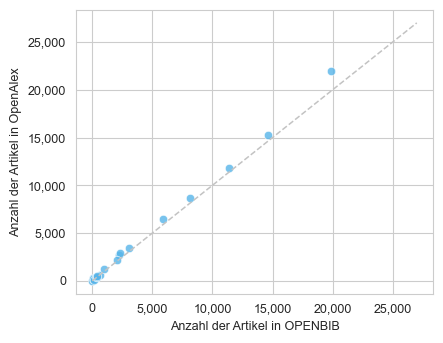

In [56]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

plt.grid(True)

t = 1.25

x = [x for x in range(0, int(inst_tab.n_oal.max() * t), 1000)]
y = x

sns.scatterplot(data=inst_tab, 
                x='n_kb', 
                y='n_oal',
                color='#56B4E9',
                alpha=0.8)

sns.lineplot(x=x, 
             y=y, 
             color='#c3c3c3', 
             linestyle='dashed', 
             linewidth=1.1,
             alpha=1)

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set(xlabel='Anzahl der Artikel in OPENBIB', ylabel='Anzahl der Artikel in OpenAlex')

plt.tight_layout()
plt.show()

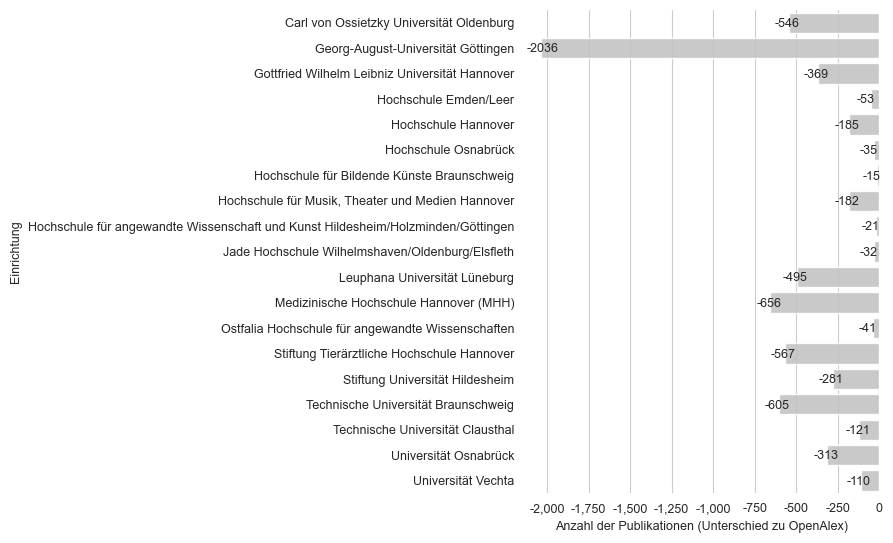

In [57]:
fig, ax = plt.subplots(figsize=(9,5.5))
plt.box(False)

change_color = ['#c3c3c3' if (x < 0) else '#56B4E9' for x in inst_tab.difference]

sns.barplot(data=inst_tab, 
            x='difference', 
            y='inst_name', 
            orient='h',
            saturation=1,
            palette=change_color,
            hue='inst_name',
            alpha=0.9,
            zorder=3,
            errorbar=None)

for idx, row in inst_tab.iterrows():
    plt.text(row['difference'] - 85, idx+0.05, row['difference'], verticalalignment='center')

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.set(xlabel='Anzahl der Publikationen (Unterschied zu OpenAlex)', ylabel='Einrichtung')

plt.tight_layout()

plt.show()